In [1]:
from wav_to_embedding import * 
import tqdm

/opt/homebrew/anaconda3/envs/voice2mode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_directory = "data"

wav_files = get_wav_files(data_directory)

hubert_embeddings = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the embedding for the current WAV file
    embedding_tensors = wav_to_embedding(file_path)
    
    # Flatten each layer's embedding and store them separately
    for layer_num, embedding_tensor in enumerate(embedding_tensors):
        embedding = embedding_tensor.detach().numpy().flatten()
        # Append the file name, label, and flattened embedding to the data list
        hubert_embeddings.append((file_path, label, layer_num, embedding))

# Convert the data list to a DataFrame
hubert_embeddings_df = pd.DataFrame(hubert_embeddings, columns=['Soundtrack', 'Label', 'Layer', 'Embedding'])

Processing WAV files:   0%|                            | 0/762 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Loading weights: 100%|████████████████████| 422/422 [00:00<00:00, 50910.24it/s]
[transformers] HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Processing WAV files: 100%|██████████████████| 762/762 [01:55<00:00,  6.57it/s]


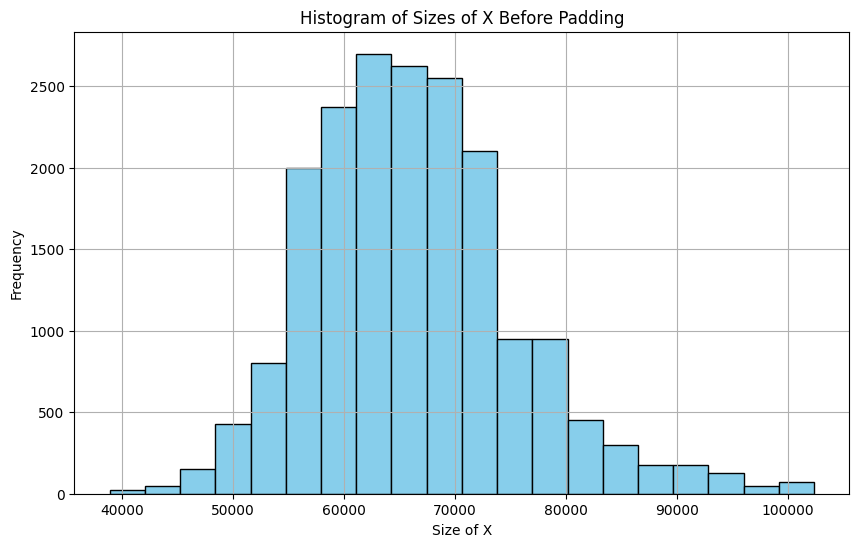

In [3]:
import matplotlib.pyplot as plt

# List to store sizes of X for each layer
sizes_before_padding = []

# Iterate through each layer
for layer_num in hubert_embeddings_df['Layer'].unique():
    # Clone the original DataFrame to preserve the original embeddings
    phonation_mode_df = hubert_embeddings_df[hubert_embeddings_df['Layer'] == layer_num].copy(deep=True)
    # Extract embeddings for the current layer
    sizes_before_padding.extend([len(embedding) for embedding in phonation_mode_df['Embedding']])

# Plotting histogram
plt.figure(figsize=(10, 6))
plt.hist(sizes_before_padding, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Sizes of X Before Padding')
plt.xlabel('Size of X')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [4]:
80000/5 #Hz

16000.0

In [5]:
len(phonation_mode_df['Embedding'][24])

60416

In [6]:
67*1024

68608

**New embedding mean method instead of flatten**

In [7]:
data_directory = "data"

wav_files = get_wav_files(data_directory)

hubert_embeddings = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the embedding for the current WAV file
    embedding_tensors = wav_to_embedding(file_path)
    
    # Flatten each layer's embedding and store them separately
    for layer_num, embedding_tensor in enumerate(embedding_tensors):
        embedding = np.mean(embedding_tensors[0].detach().numpy(), axis=1)[0]
        # Append the file name, label, and flattened embedding to the data list
        hubert_embeddings.append((file_path, label, layer_num, embedding))

# Convert the data list to a DataFrame
hubert_embeddings_df = pd.DataFrame(hubert_embeddings, columns=['Soundtrack', 'Label', 'Layer', 'Embedding'])

Processing WAV files: 100%|██████████████████| 762/762 [01:59<00:00,  6.40it/s]


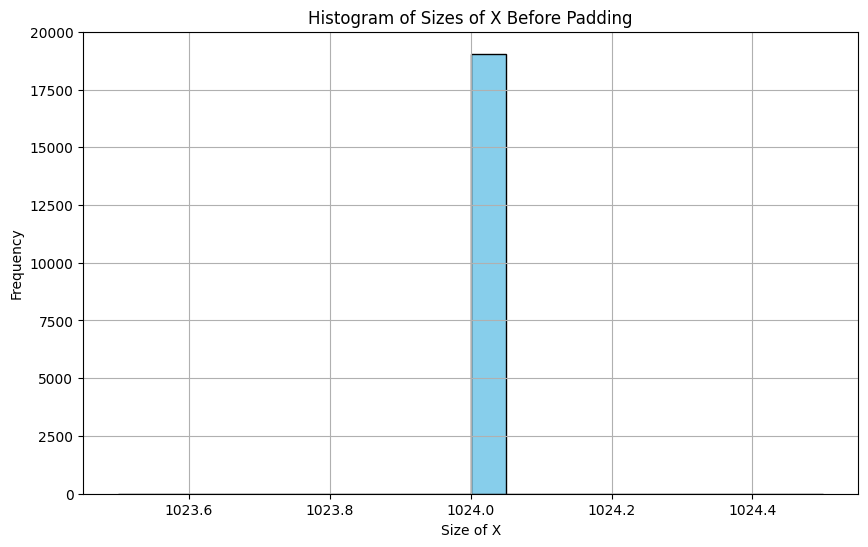

In [8]:
import matplotlib.pyplot as plt

# List to store sizes of X for each layer
sizes_before_padding = []

# Iterate through each layer
for layer_num in hubert_embeddings_df['Layer'].unique():
    # Clone the original DataFrame to preserve the original embeddings
    phonation_mode_df = hubert_embeddings_df[hubert_embeddings_df['Layer'] == layer_num].copy(deep=True)
    # Extract embeddings for the current layer
    sizes_before_padding.extend([len(embedding) for embedding in phonation_mode_df['Embedding']])

# Plotting histogram
plt.figure(figsize=(10, 6))
plt.hist(sizes_before_padding, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Sizes of X Before Padding')
plt.xlabel('Size of X')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
